In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd 

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [2]:
from PINN import models
import matplotlib.pyplot as plt

In [3]:
from PINN import models

# define the velocity and then simuate the coordinates

Suppose we have n dimensional initital cells. Each coordinate is independent of each other

In [21]:
from torchdiffeq import odeint
import phate

In [50]:
n_knot = 5
n_smooth = 1
n_dimension = 5

def generate_positive_knot(n_knot, n_smooth = 1):
    """
    randomly return `n` knots with the minimum value placed as the first one
    """
    # max_height = np.random.randint(0,50)/100
    base = np.random.randint(low=0, high=30, size=(n_knot+n_smooth,))/100 + np.random.random((n_knot+n_smooth,))/10

    # smoothed the 
    for i in range(n_smooth):
        base = (base[:-1]+base[1:]) / 2 
    
    vmin = np.min(base)
    rest = [v for v in base if v!= vmin]
    knots = [vmin] + rest
    return np.array(knots)

def generate_v_knots(n_dimension, n_knot, n_smooth = 1):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        positive_base = generate_positive_knot(n_knot, n_smooth)

        negative_base = -1 * generate_positive_knot(n_knot, n_smooth)[::-1]

        v_knots_i = [0] + list(negative_base) + list(positive_base) + [0]

        all_knots.append(v_knots_i)
    v_knots = np.stack(all_knots)

    X_knots = []
    for d in range(n_dimension):
        DM_max = np.random.randint(30,80)/10
        X_knots.append(torch.linspace(-1*DM_max, DM_max, 12).float())

    x_knots = torch.stack(X_knots)

    for n in range(n_dimension):
    
        if np.random.random() < 0.5:
            # for negative 
            loc = np.random.randint(1,5)
            v_knots[n, loc] = 0.1 * v_knots[n, loc]
            v_knots[n, loc+1] = 3 * v_knots[n, loc+1]
            print(n,loc)

        if np.random.random() < 0.5:
            # for negative 
            loc = np.random.randint(6,10)
            v_knots[n, loc] = 3 * v_knots[n, loc]
            v_knots[n, loc+1] = 0.1 * v_knots[n, loc+1]
            print(n,loc)


    return x_knots, torch.from_numpy(v_knots)

def generate_g_knots(n_dimension, n_knot, high=50):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        base = np.random.randint(low=0, high=high, size=(n_knot,))/100
        
        all_knots.append(base)
    g_knots = np.stack(all_knots)


    if np.random.random() < 0.5: # for negative 
        loc = np.random.randint(0,5)
        g_knots[:,loc] = g_knots[:,loc] * 3

    if np.random.random() < 0.5: # for negative 
        loc = np.random.randint(6,11)
        g_knots[:,loc] = g_knots[:,loc] * 3

    return torch.from_numpy(g_knots).float()

def generate_D_knots(n_dimension, n_knot):
    """
    generate n dimensional knot groups
    """
    all_knots = []
    for d in range(n_dimension):

        base = np.random.randn(n_knot)/100
        
        all_knots.append(base)
    y_knots = np.stack(all_knots)

    return torch.from_numpy(y_knots).float()

In [295]:
def plot_timepoints(trajectory, trajectory_noised=None, timepoint_index=[1, 3,5, 7, 9], dim=[0,1]):

    n_time = len(timepoint_index)

    fig, axs = plt.subplots(1, n_time, figsize=(2.3*n_time,2), dpi=60, sharex=True, sharey=True)
    for i, t in enumerate(timepoint_index):
        axs[i].scatter(trajectory[0, :,dim[0]], trajectory[0, :,dim[1]], color='grey', alpha=0.3, s=6)
        axs[i].scatter(trajectory[t,:,dim[0]], trajectory[t,:,dim[1]], color='#383D67', alpha=0.8, s=6)
        axs[i].set_title(t)
        axs[-1].legend(['starting cell', 'simulated by ode'], ncols=2, bbox_to_anchor=(-0.5,1.2,0.3,0.05))
    
    if trajectory_noised is not None:
        fig2, axs2 = plt.subplots(1, n_time, figsize=(2.3*n_time,2), dpi=100, sharex=True, sharey=True)
        for i, t in enumerate(timepoint_index):
            axs2[i].scatter(trajectory_noised[0, :,dim[0]], trajectory_noised[0, :,dim[1]], color='grey', alpha=0.3, s=6)
            axs2[i].scatter(trajectory_noised[t,:,dim[0]], trajectory_noised[t,:,dim[1]], color='#E39B8C', alpha=0.8, s=6)
            axs2[-1].legend(['starting cell', 'simulated by sde'], ncols=2, bbox_to_anchor=(-0.5,1.2,0.3,0.05))

def plot_phate(trajectory, timepoint_index=[1, 3, 5, 7, 9]):

    n_cell = trajectory.shape[1]
    all_data = trajectory.reshape(-1,5)
    phate_op = phate.PHATE(knn=15, verbose=False)
    X_phate = phate_op.fit_transform(all_data);

    X_phate = X_phate.reshape(-1,n_cell, 2)

    n_cols = len(timepoint_index)+1

    fig, axs = plt.subplots(1, n_cols, figsize=(2.3*n_cols,2), dpi=60, sharex=True, sharey=True)
    for i, t in enumerate(timepoint_index):
        axs[i].scatter(X_phate[0, :, 0], X_phate[0, :,1], color='grey', alpha=0.3, s=6)
        axs[i].scatter(X_phate[t,:, 0], X_phate[t,:,1], color='#383D67', alpha=0.8, s=6)
        axs[i].set_title(t)
    
    X_phate = X_phate.reshape(-1, 2)

    axs[-1].scatter(X_phate[:, 0], X_phate[:,1], color='grey', alpha=0.3, s=6)
    axs[-1].scatter(X_phate[:, 0], X_phate[:,1], color='#383D67', alpha=0.8, s=6)
    axs[-1].set_title('all')
    axs[-1].legend(['starting cell', 'simulated by ode'], ncols=2, bbox_to_anchor=(-0.5,1.3,0.3,0.05))

    return X_phate, phate_op

def plot_different_dim(trajectory):

    plot_timepoints(trajectory, dim=[0,1])
    plot_timepoints(trajectory, dim=[2,3])
    plot_timepoints(trajectory,  dim=[0,4])
    # plot_phate(trajectory)
    

# simulate random cells

In [5]:
starting_cells = []
starting_cells.append(torch.randn(500, 5).float() / 4)
starting_cells.append(torch.randn(500, 5).float() / 16 + torch.randn((1,5)) / 4) 
starting_cells.append(torch.randn(500, 5).float() / 16 + torch.randn((1,5)) / 4) 
starting_cells.append(torch.randn(500, 5).float() / 8 + torch.randn((1,5)) / 4) 

starting_cells = torch.cat(starting_cells, dim=0).float()

velocity

In [6]:
# syn_init_ckpt = torch.load("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_init_condition.ckpt")
# cellstate = syn_init_ckpt['cellstate']
# starting_cells = cellstate[:250]
# alldata = cellstate.numpy()

In [7]:
from torchdiffeq import odeint
import phate

In [8]:
device = 'cuda:5'

In [9]:
x_knots, v_knots = generate_v_knots(5, 5, 0)
v_cs = models.MultiDim_CubicSpline(y=v_knots.T, x=x_knots.T)

0 3
1 3
2 6
3 7
4 8


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


Text(0.5, 0, 'time')

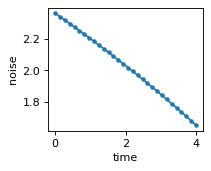

In [10]:
def odefun(t, cs):
    return v_cs(cs)

def epsilon(t):
    return (10-t)**0.5 - 0.8

def sdefun(t, cs):
    v = v_cs(cs)
    noise = torch.randn_like(v) * epsilon(t)
    return v+ noise


t = np.linspace(0,4,30)
D = epsilon(t)

fig, axs = plt.subplots(1,1, figsize=(2.5,2), dpi=80)
plt.plot(t, D, marker='.')
plt.ylabel("noise")
plt.xlabel("time")

In [338]:
# simulate cell state should have one more timepoit
integrat_time = torch.linspace(0, 4.4, 12).float()


with torch.no_grad():
    trajectory = odeint(odefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)

starting_coords = starting_cells.numpy()
trajectory = trajectory.cpu().numpy()


# try simulate celll with noise
with torch.no_grad():
    trajectory_noised = odeint(sdefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)

test_noised = trajectory_noised.cpu().numpy()



/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


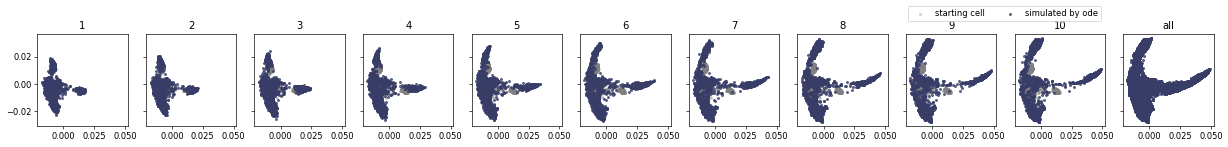

In [340]:
X_phate_test, phate_op_test = plot_phate(test_noised, timepoint_index=np.arange(1,11))

In [341]:
deltax = np.diff(trajectory, axis=0)
print(deltax.shape)
param_ckpt = {
    'v' : v_knots,
    'trajectory' : trajectory,
    "trajectory_noised" : trajectory_noised,
    "integrat_time" : integrat_time,
    "deltax" : deltax 
}
torch.save(param_ckpt, "data/synthesized_data/5Dim_ncs_synparam_Jan23/triangle_traj_v_0-4.ckpt")

(11, 2000, 5)


In [23]:
integrat_time = torch.linspace(0, 6, 11).float()

with torch.no_grad():
    trajectory = odeint(odefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)

starting_coords = starting_cells.numpy()
trajectory = trajectory.cpu().numpy()


# try simulate celll with noise
with torch.no_grad():
    trajectory_noised = odeint(sdefun, 
                    y0=starting_cells.clone().to(device), 
                    t=integrat_time, 
                    atol=1e-4, rtol=1e-4)

trajectory_noised = trajectory_noised.cpu().numpy()



/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


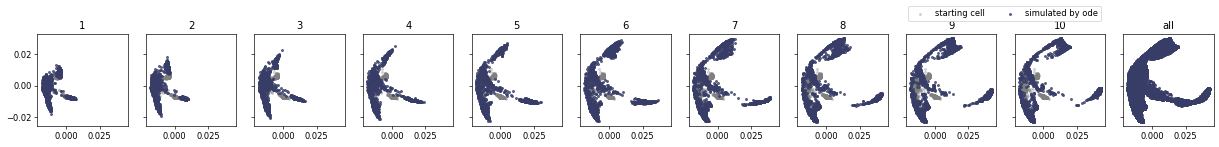

In [74]:
X_phate, phate_op = plot_phate(trajectory, timepoint_index=np.arange(1,11))

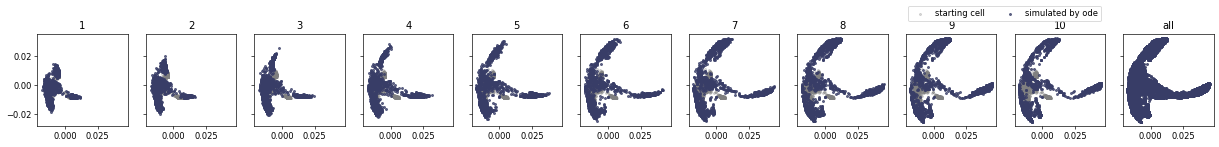

In [75]:
X_phate_noised, phate_op_noised = plot_phate(trajectory_noised, timepoint_index=np.arange(1,11))

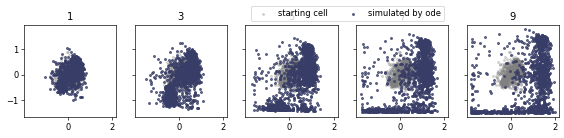

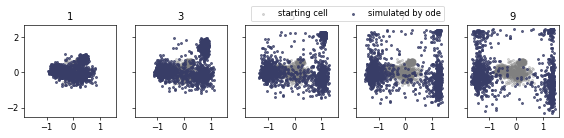

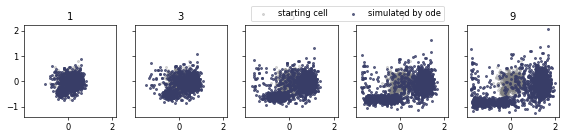

In [296]:
plot_different_dim(trajectory)

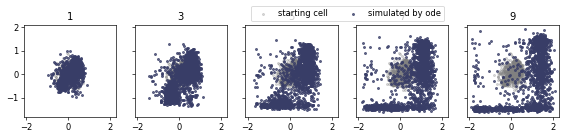

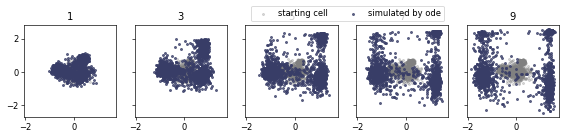

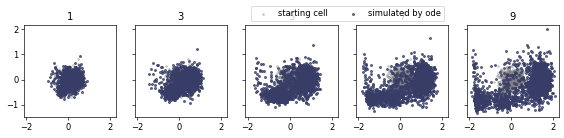

In [297]:
plot_different_dim(trajectory_noised)

In [35]:
ds = np.diff(trajectory, axis=0)
print(ds.shape)
param_ckpt = {
    'v' : v_knots,
    'trajectory' : trajectory,
    "trajectory_noised" : trajectory_noised,
    "ds" : ds 
}
# torch.save(param_ckpt, "data/synthesized_data/5Dim_ncs_synparam_Jan23/triangle_traj_v.ckpt")

(10, 2000, 5)

# convert to anData

In [130]:
import anndata as ad

## 0-4

In [356]:
# define obs
n_cell = 2000
integrate_time = np.linspace(0, 4, 11)
sampled_time = np.array([[integrate_time[i]]*n_cell for i in range(0,11)]).flatten()

cb = []
source_cell = []
for i in range(0,11):
    t = integrate_time[i]
    cb.append([f"t{t}_c{c}" for c in range(n_cell)])
    source_cell.append([f"c{c}" for c in range(n_cell)])

cb = np.stack(cb).flatten()
sources = np.stack(source_cell).flatten()

obs = pd.DataFrame(
    {"time":sampled_time,
     "cb":cb, "source":sources}
)
obs = obs.set_index('cb')

# define var
var = pd.DataFrame({"name":["DM_%s"%i for i in range(5)]}).set_index("name")


syn_ad_4 = ad.AnnData( X = test_noised[:-1].reshape(-1,n_dimension),
           obs =  obs,
           var = var
           )

syn_ad_4.obsm['X_data'] = syn_ad_4.X
syn_ad_4.obsm['X_umap'] = X_phate_test[:22000]
syn_ad_4.obsm['X_phate'] = X_phate_test[:22000]
syn_ad_4.obsm['Delta_DM'] = deltax.reshape(-1,n_dimension)
syn_ad_4.obs['timepoint'] = syn_ad_4.obs['time'].astype(str)

syn_ad_4

AnnData object with n_obs × n_vars = 22000 × 5
    obs: 'time', 'source', 'timepoint'
    obsm: 'X_data', 'X_umap', 'X_phate', 'Delta_DM'

In [357]:
syn_ad_4.write_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell_0_4.h5ad")

## 0-6

In [350]:
# define obs
n_cell = starting_cells.shape[0]
integrate_time = np.linspace(0, 6, 11)
sampled_time = np.array([[integrate_time[i]]*n_cell for i in range(0,11,2)]).flatten()

cb = []
source_cell = []
for i in range(0,11):
    t = integrate_time[i]
    cb.append([f"t{t}_c{c}" for c in range(n_cell)])
    source_cell.append([f"c{c}" for c in range(n_cell)])

cb = np.stack(cb).flatten()
sources = np.stack(source_cell).flatten()

obs = pd.DataFrame(
    {"time":sampled_time,
     "cb":cb, "source":sources}
)
obs = obs.set_index('cb')

# define var
var = pd.DataFrame({"name":["DM_%s"%i for i in range(5)]}).set_index("name")


syn_ad = ad.AnnData( X = trajectory_noised[:-1].reshape(-1,n_dimension),
           obs =  obs,
           var = var
           )

syn_ad.obsm['X_data'] = syn_ad.X
syn_ad.obsm['X_umap'] = X_phate_noised
syn_ad.obsm['X_phate'] = X_phate_noised
syn_ad.obs['timepoint'] = syn_ad.obs['time'].astype(str)

syn_ad

ValueError: All arrays must be of the same length

In [ ]:
syn_ad.write_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell.h5ad")

In [285]:
import scanpy as sc

In [286]:
sc.pp.neighbors(syn_ad, n_neighbors=5, use_rep='X_data')
sc.tl.leiden(syn_ad, resolution=1)
sc.tl.leiden(syn_ad, resolution=0.1, key_added='leiden_rs0.1')

/tmp/ipykernel_18852/3480520612.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(syn_ad, resolution=1)


In [287]:
syn_ad.write_h5ad("data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_cell.h5ad")

# simulate g and D

/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


Text(0.5, 1.0, 'diffuse')

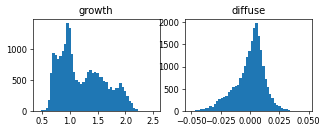

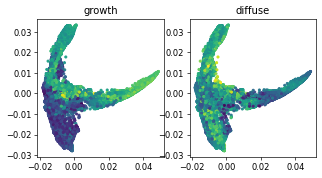

In [359]:
cellstate = trajectory_noised.reshape(-1,5)
X_ph = X_phate_noised

cellstate = test_noised[:-1].reshape(-1,5)
X_ph = X_phate_test[:22000]

# g_knots = generate_g_knots(5,12) * 1.6
g_cs = models.MultiDim_CubicSpline(y=g_knots.T , x=x_knots.T, collapse=True)

# D_knots = generate_D_knots(5,12)
D_cs = models.MultiDim_CubicSpline(y=D_knots.T, x=x_knots.T, collapse=True)

growth = g_cs(cellstate,None).detach().cpu().numpy().flatten()
diffuse = D_cs(cellstate,None).detach().cpu().numpy().flatten()

fig, axs = plt.subplots(1,2, figsize=(6,2), dpi=60)
axs[0].hist(growth, bins=50);
axs[1].hist(diffuse, bins=50);
axs[0].set_title('growth')
axs[1].set_title('diffuse')

fig, axs = plt.subplots(1,2, figsize=(6,3), dpi=60)
axs[0].scatter(X_ph[:,0], X_ph[:,1], c=growth, s=7)
axs[1].scatter(X_ph[:,0], X_ph[:,1], c=diffuse, s=7)
axs[0].set_title('growth')
axs[1].set_title('diffuse')

In [ ]:
ncs_ckpt = {
    'v' : v_knots,  'g' : g_knots ,  'D' : D_knots,  'x' : x_knots,
}
torch.save(ncs_ckpt, "data/synthesized_data/5Dim_ncs_synparam_Jan23/biomodal_g_norm_D_params_0_4.ckpt")

# init duds

In [83]:
from torch import nn
from torchdiffeq import odeint
from scipy.stats import gaussian_kde

In [86]:
class Syn_model(nn.Module):

    def __init__(self, g_model, v_model, D_model):
        super().__init__()
        self.g = g_model
        self.v = v_model
        self.D = D_model
        self.relu = nn.ReLU()
    
    def gradient_of(self, out, variable):
        return torch.autograd.grad(out, variable, create_graph=True, allow_unused=True)[0] 

    
    def forward(self, t, states):
        """
        the ODE function used for odeint
        """
        u = self.relu(states[0])
        s = states[1]
        duds = states[2]
        device = s.device

        with torch.set_grad_enabled(True):
            
            u = u.requires_grad_(True).float()
            s = s.requires_grad_(True).float()
            duds = duds.requires_grad_(True).float()

            # u = torch.exp(self.u(s, t_in)) # make sure it is u but not log u

            D = self.D(s,None)
            v = self.v(s,None)
            g = self.g(s,None).flatten()
            
            # the first order deviritives of density u to time : ∂u/∂s

            duds_backward = self.gradient_of(u.sum(), s)
            if duds_backward is None:
                # print(t)
                duds = duds.requires_grad_(True)
            else:
                duds = duds_backward
            
            
            # the first term:  a second order derivative
            Du = torch.mul(D, duds)   # element-wise 
            d2Dds2 = self.gradient_of(Du.sum(), s)  
            
            # the second term : ∂/∂s[ v*u ]
            dvds_ls  = []
            for i in range(v.shape[1]):
                du_dsisi = self.gradient_of(v[:,i].sum(), s)[:, i:i+1]
                dvds_ls.append(du_dsisi)
            dvds = torch.cat(dvds_ls, dim=1)
            # print(dvds.shape)
            # print(u.shape)
            dvuds = dvds * u.reshape(-1,1) + torch.mul(duds, v)
            
            # right hand side
            diffuse = d2Dds2.sum(dim=1)
            drift = dvuds.sum(dim=1)
            growth = torch.mul(g, u)

            dudt = growth - drift + diffuse

            # set ds to zeros to fix cellstates
            dsdt = torch.zeros_like(s).float().to(device).requires_grad_(True)

            # duds_by_time = dsdt  
            duds_by_time = self.gradient_of(dudt.sum(), s)

            

        return dudt, dsdt, duds_by_time, growth , drift , diffuse

# simulate

In [95]:
device='cuda:6'

In [371]:
v_cs = models.MultiDim_CubicSpline(y=v_knots.T, x=x_knots.T)
g_cs = models.MultiDim_CubicSpline(y=g_knots.T*1.6 , x=x_knots.T, collapse=True)
D_cs = models.MultiDim_CubicSpline(y=D_knots.T, x=x_knots.T, collapse=True)

model = Syn_model(g_cs, v_cs, D_cs).to(device)


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/models/Spline_models.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("x", torch.tensor(x, dtype=torch.float32, requires_grad=False))


In [372]:
# can change to trajectory w.o noise
all_data_bytime = trajectory_noised
all_data = trajectory_noised.reshape(-1,5) 

In [373]:
test_noised[:-1].shape

(11, 2000, 5)

In [374]:
# can change to trajectory w.o noise
all_data_bytime = test_noised[:-1]
all_data = all_data_bytime.reshape(-1,5) 

Text(0.5, 1.0, '4')

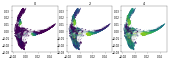

In [375]:
kde_fn_init = gaussian_kde(all_data_bytime[0].T, bw_method=1.5)
u_all = kde_fn_init(all_data.T)
kde_fn_last = gaussian_kde(all_data_bytime[3].T, bw_method=2)
u_all_2 = kde_fn_last(all_data.T)
kde_fn_last = gaussian_kde(all_data_bytime[5].T, bw_method=2)
u_all_4 = kde_fn_last(all_data.T)

fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=20)
axs[0].scatter(X_ph[:,0], X_ph[:,1], c=u_all, s=1, alpha=0.2)
axs[1].scatter(X_ph[:,0], X_ph[:,1], c=u_all_2, s=1, alpha=0.2)
axs[2].scatter(X_ph[:,0], X_ph[:,1], c=u_all_4, s=1, alpha=0.2)
axs[0].set_title(0)
axs[1].set_title(2)
axs[2].set_title(4)

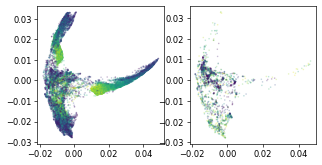

In [376]:
keep_index =  np.where(u_all_last>=0.00075)[0]

remove_index =  np.where(u_all_last<=0.00075)[0]

fig, axs = plt.subplots(1,2, figsize=(6,3), dpi=60)
axs[0].scatter(X_ph[keep_index,0], X_ph[keep_index,1], c=u_all_last[keep_index], s=1, alpha=0.2)
axs[1].scatter(X_ph[remove_index,0], X_ph[remove_index,1], c=u_all_last[remove_index], s=1, alpha=0.2)

In [377]:
dm_range = all_data.max(axis=0) - all_data.min(axis=0)
ds = dm_range / 1000

du_dcs_t = []
for dim in range(n_dimension):
    dcs = np.zeros_like(all_data)
    dcs[:,dim] = np.full((dcs.shape[0],), ds[dim])
    s_prime = all_data + dcs

    dudcs_dim = (kde_fn_init(s_prime.T) - kde_fn_init(all_data.T)) / ds[dim]
    du_dcs_t.append(dudcs_dim)


du_dcs_t = torch.from_numpy(np.stack(du_dcs_t).T) 

In [378]:
du_dcs_t.shape

torch.Size([22000, 5])

In [379]:
du_dcs_t = du_dcs_t.float().to(device) / u_all.sum()
u_init = torch.from_numpy(u_all).float().to(device) / u_all.sum()
cellstate = torch.from_numpy(all_data).float().to(device)

zeros = torch.zeros_like(u_init)
init = (u_init, cellstate, du_dcs_t, zeros, zeros, zeros)

In [380]:
sim_out = odeint(
    model, init, t=torch.linspace(0, 4, 11).float(),
    rtol=1e-4, atol=1e-5,    
)

torch.cuda.empty_cache()

u_sim = model.relu(sim_out[0]).detach().cpu().numpy()
print(u_sim.sum(axis=1))

growth = sim_out[3].detach().cpu().numpy()
drift = sim_out[4].detach().cpu().numpy()
diffuse = sim_out[5].detach().cpu().numpy()
del sim_out

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


[9.99999940e-01 1.34495413e+00 1.70219898e+00 1.96175444e+00
 2.38580441e+00 3.66277170e+00 7.82881689e+00 2.73182945e+01
 1.25419815e+02 6.58657166e+02 3.69976245e+03]


Text(0, 0.5, 'diffuse')

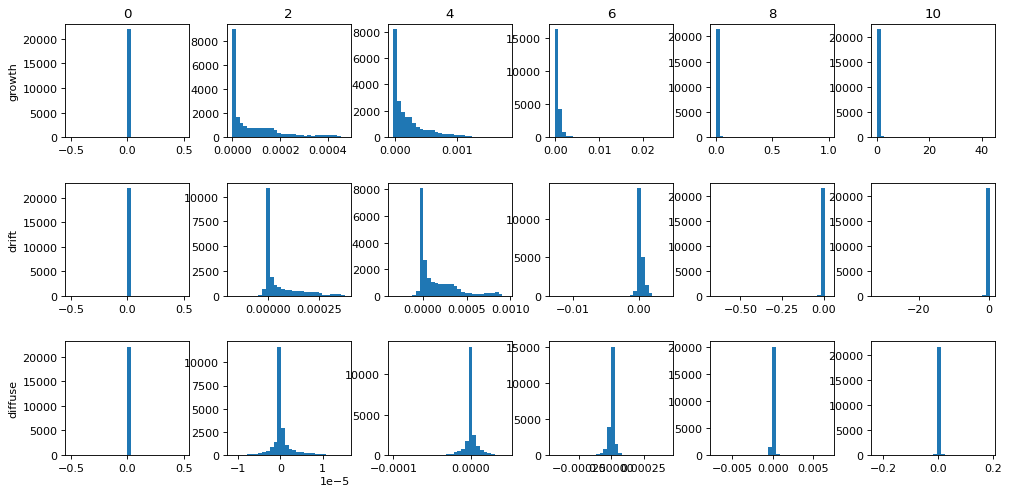

In [316]:
timeppoint_index = np.arange(0,11,2)
n_cols = len(timeppoint_index)

fig, axs = plt.subplots(3, n_cols, figsize=(2.5*n_cols, 7), dpi=80, gridspec_kw={"hspace":0.4, 'wspace':0.3})

for i,t in enumerate(timeppoint_index):
    axs[0,i].hist(growth[t], bins=30, label='growth')
    axs[1,i].hist(drift[t], bins=30, label='drift')
    axs[2,i].hist(diffuse[t], bins=30, label='diffuse')

    axs[0,i].set_title(t)

axs[0,0].set_ylabel('growth')
axs[1,0].set_ylabel('drift')
axs[2,0].set_ylabel('diffuse')

In [160]:
syn_ad.uns['pop'] =  {
        't': np.around(integrate_time, decimals=2),
        'mean' :  u_sim.sum(axis=1)}

In [159]:
integrate_time

array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ])

convert to adata

In [155]:
import PINN

prediction of shape (11, 22000)


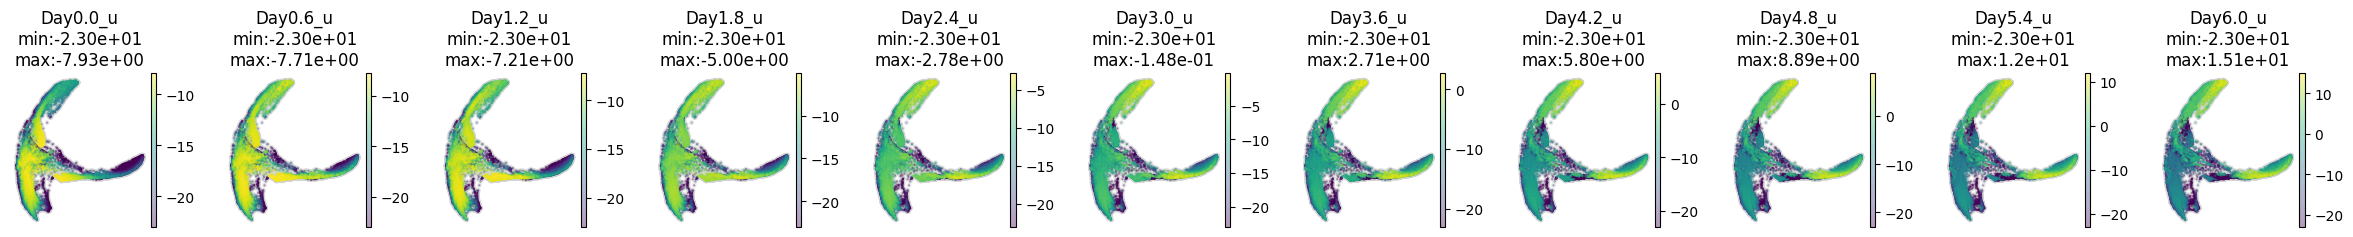

In [293]:
log_u = np.log(u_sim+1e-10)
# log_u = np.clip(log_u, a_min=-40, a_max=None)
PINN.pl.params_in_umap(syn_ad, log_u, cell_of_t=False, umap_kws={'s':10, 'alpha':0.4});

prediction of shape (11, 22000)


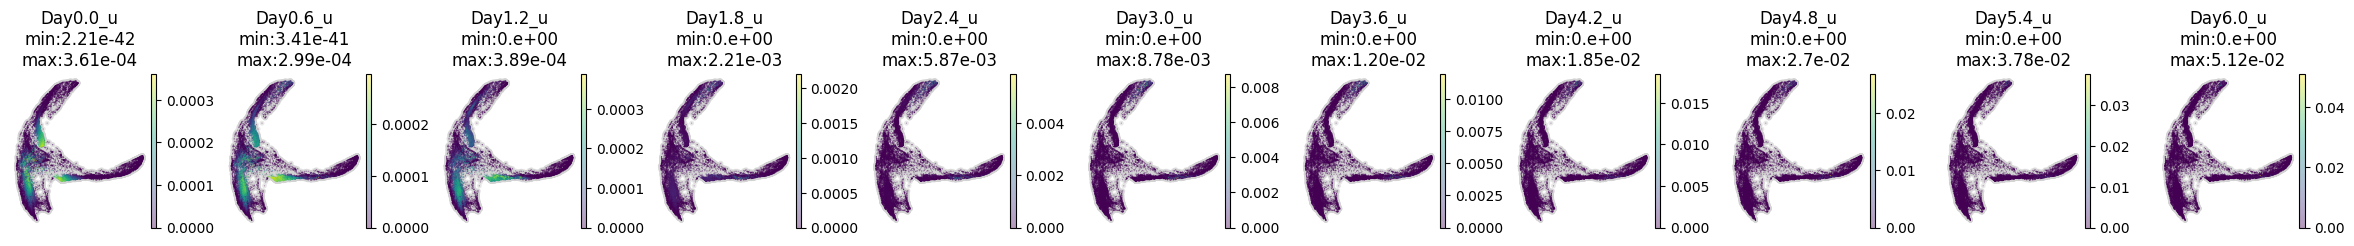

In [273]:
u_norm = u_sim / u_sim.sum(axis=1,keepdims=True)

PINN.pl.params_in_umap(syn_ad, u_sim, cell_of_t=False, umap_kws={'s':10, 'alpha':0.4});

In [386]:
np.sum(u_sim == 0, axis=1)

array([   0,    0,    0,  114,  871, 1665, 2557, 3611, 4602, 5374, 6001])

In [279]:
integrat_time# = np.linspace(0, 2, 11)

tensor([0.0000, 0.6000, 1.2000, 1.8000, 2.4000, 3.0000, 3.6000, 4.2000, 4.8000,
        5.4000, 6.0000])

In [331]:
du_dcs_t.shape

torch.Size([22000, 5])

In [382]:
trajectory.shape

(12, 2000, 5)

## 0-4

In [384]:
integrat_time

tensor([0.0000, 0.4000, 0.8000, 1.2000, 1.6000, 2.0000, 2.4000, 2.8000, 3.2000,
        3.6000, 4.0000, 4.4000])

In [387]:
integrat_time = torch.linspace(0, 4, 11)

synthesize_condition = {  "u_init": u_init.cpu(), 
    "cellstate":torch.from_numpy(all_data).float(), 
    "duds" : du_dcs_t.cpu(),
    "integrate_time": integrat_time
}
torch.save(synthesize_condition, "data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_init_condition_0-4.ckpt")

deltax = np.diff(trajectory, axis=0)
simulate_result = {
    "u_simulate" : torch.from_numpy(u_sim).float(),
    "integrate_time": integrat_time,
    "delta_x" : torch.from_numpy(deltax).float().reshape(-1,5)
}
torch.save(simulate_result, "data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_result_0-4.ckpt")

ncs_ckpt = {
    'v' : v_knots,  'g' : g_knots*1.6 ,  'D' : D_knots,  'x' : x_knots,
}
torch.save(ncs_ckpt, "data/synthesized_data/5Dim_ncs_synparam_Jan23/biomodal_g_norm_D_params_0_4.ckpt")

## 0-6

In [ ]:
synthesize_condition = {  "u_init": u_init.cpu(), 
    "cellstate":cellstate.cpu(), 
    "duds" : du_dcs_t.cpu(),
    "integrate_time": integrat_time
}
torch.save(synthesize_condition, "data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_init_condition_0-6.ckpt")

ds = np.diff(trajectory, axis=0)
simulate_result = {
    "u_simulate" : torch.from_numpy(u_sim).float(),
    "integrate_time": integrat_time,
    "delta_x" : torch.from_numpy(ds).float()
}
torch.save(simulate_result, "data/synthesized_data/5Dim_ncs_synparam_Jan23/syn_result.ckpt")